In [81]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as rcParams
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import warnings
warnings.simplefilter(action = "ignore")
sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [82]:
data = pd.read_csv("C:/DEPI/Amit/Src/ML/Session_8/code/PlayTennis.csv")
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Wind         14 non-null     object
 4   Play Tennis  14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes


In [84]:
from sklearn.preprocessing import OrdinalEncoder
outlook_encoder = OrdinalEncoder()
data["Outlook"] = outlook_encoder.fit_transform(data[["Outlook"]])
temp_encoder = OrdinalEncoder()
data["Temperature"] = temp_encoder.fit_transform(data[["Temperature"]])
humidity_encoder = OrdinalEncoder()
data["Humidity"] = humidity_encoder.fit_transform(data[["Humidity"]])
wind_encoder = OrdinalEncoder()
data["Wind"] = wind_encoder.fit_transform(data[["Wind"]])
play_encoder = OrdinalEncoder()
data["Play Tennis"] = play_encoder.fit_transform(data[["Play Tennis"]])
data.head()


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0


In [85]:
x = data.drop(['Play Tennis'], axis=1)
y = data['Play Tennis']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)


In [86]:
dtc = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc.fit(x_train, y_train)
y_pred_gini = dtc.predict(x_test)

In [87]:
dtc_2 = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_2.fit(x_train, y_train)
y_pred_entropy = dtc_2.predict(x_test)

Accuracy with gini criterion: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



<Axes: >

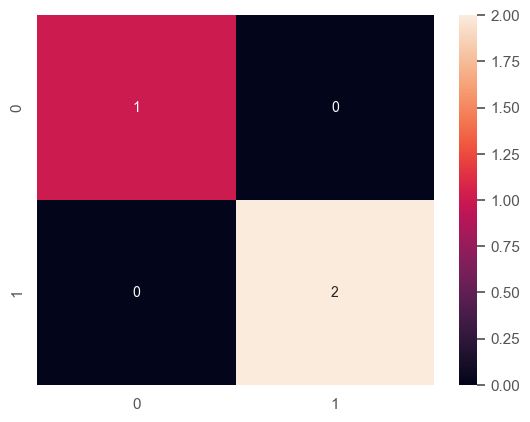

In [88]:
print("Accuracy with gini criterion:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))
sns.heatmap(confusion_matrix(y_test, y_pred_gini), annot=True, fmt='d')

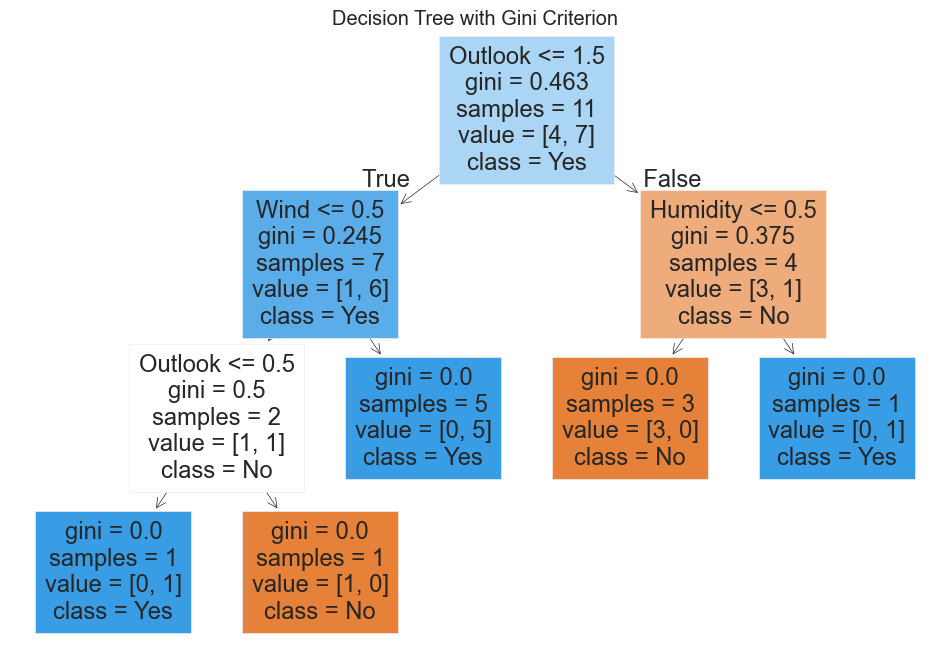

In [90]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(dtc, filled=True, feature_names=x.columns, class_names=['No', 'Yes'])
plt.title("Decision Tree with Gini Criterion")
plt.show()

Accuracy with entropy criterion: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



<Axes: >

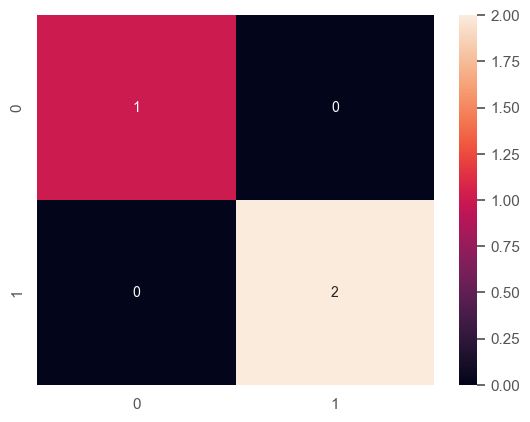

In [89]:
print("Accuracy with entropy criterion:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))
sns.heatmap(confusion_matrix(y_test, y_pred_entropy), annot=True, fmt='d')

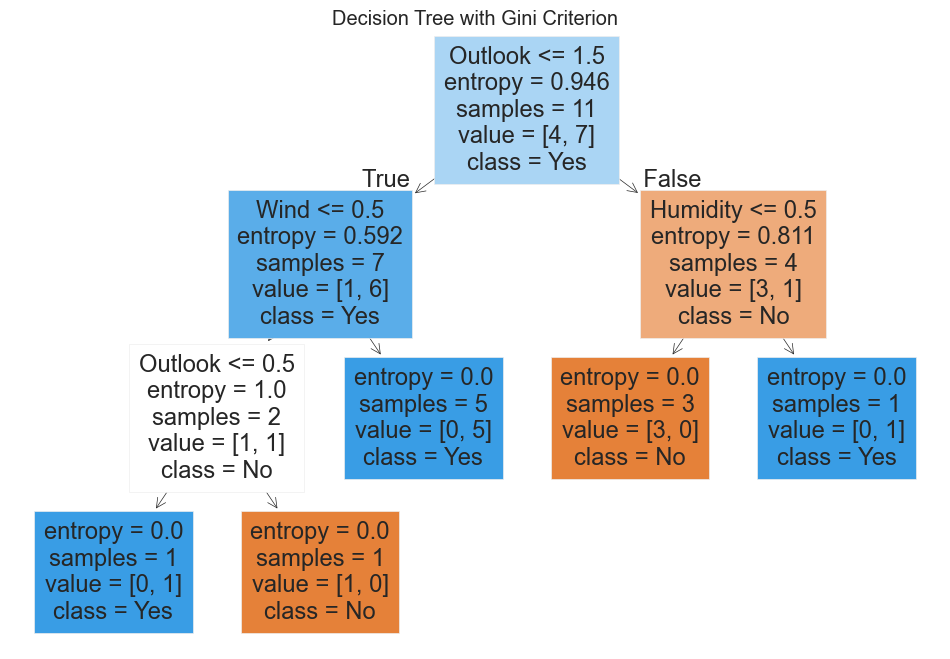

In [ ]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(dtc_2, filled=True, feature_names=x.columns, class_names=['No', 'Yes'])
plt.title("Decision Tree with Entropy Criterion")
plt.show()